In [ ]:
import pandas as pd
import numpy as np
import json
import joblib
import optuna

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# =========================
# 1. 读取数据
# =========================
df0 = pd.read_excel("Dataset_DFT.xlsx")
df = df0.copy()

# 如需删除无关列，可取消注释
df.drop(columns=["Type", "DBPs","DOI", "Code", "DBP_group"], inplace=True)


# =========================
# 2. 定义输入和输出
# =========================
target_col = "C"

X = df.drop(columns=[target_col])
y = df[target_col]


# =========================
# 3. 定义需要归一化的列
# =========================
numerical_cols_to_scale = [
    "DOC", "UV254", "Br", "TN", "Chlorine dose", "Disinfection time",
    "Temperature", "pH", "C1", "C2", "LMW", "MMW", "HMW",
    "Es", "EHOMO", "ELUMO", "Egap"
]


# =========================
# 4. 先划分训练集和测试集
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=98
)


# =========================
# 5. 构建预处理器
# 只归一化指定列，其余列保持不变
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), numerical_cols_to_scale)
    ],
    remainder="passthrough"
)

# =========================
# 导出完整列，并保持与 train_raw/test_raw 相同的样本顺序
# =========================

# 按 X_train_raw 和 X_test_raw 的实际顺序提取原始完整数据
train_full = df0.loc[X_train_raw.index].copy()
test_full = df0.loc[X_test_raw.index].copy()

# 添加数据集标记
train_full["Dataset_split"] = "Training"
test_full["Dataset_split"] = "Test"

# 先放训练集，再放测试集
dataset_full = pd.concat(
    [train_full, test_full],
    axis=0,
    ignore_index=True
)

dataset_full.to_excel(
    "Dataset_train_test_split.xlsx",
    index=False
)

print("训练集样本数：", len(train_full))
print("测试集样本数：", len(test_full))
print("完整数据已保存至 Dataset_train_test_split.xlsx")

训练集样本数： 1854
测试集样本数： 464
完整数据已保存至 Dataset_train_test_split.xlsx


In [37]:
# =========================
# 6. Optuna 贝叶斯优化
# =========================
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.003, 0.2, log=True),

        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.5, 1.0),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 20.0, log=True),

        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "tree_method": "hist",

        "grow_policy": trial.suggest_categorical(
        "grow_policy",
        ["depthwise", "lossguide"]
        ),

        "max_leaves": trial.suggest_int("max_leaves", 16, 128),

        # 损失函数
        "objective": trial.suggest_categorical(
         "objective",
        [
            "reg:squarederror",
            "reg:pseudohubererror"
        ]
        ),
        
        "random_state": 98,
        "n_jobs": 1,
        }

    model = XGBRegressor(**params)

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    cv = KFold(
        n_splits=10,
        shuffle=True,
        random_state=98
    )

    scores = cross_val_score(
        pipe,
        X_train_raw,
        y_train,
        scoring="r2",
        cv=cv,
        n_jobs=1
    )

    return np.mean(scores)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best CV R2:", study.best_value)
print("Best params:", study.best_params)

[I 2026-07-23 20:58:11,408] A new study created in memory with name: no-name-9d6d263b-9331-414b-a791-8513e39510f8
Best trial: 0. Best value: 0.831204:   2%|▏         | 1/50 [00:03<02:38,  3.24s/it]

[I 2026-07-23 20:58:14,650] Trial 0 finished with value: 0.8312038542892338 and parameters: {'n_estimators': 506, 'max_depth': 10, 'learning_rate': 0.02863780574415542, 'subsample': 0.7237724924551897, 'colsample_bytree': 0.69702431734107, 'colsample_bylevel': 0.6202949772177704, 'colsample_bynode': 0.6135220548572954, 'reg_alpha': 0.012064334320671595, 'reg_lambda': 0.021597787442393195, 'gamma': 1.7586237220568501, 'min_child_weight': 8, 'grow_policy': 'depthwise', 'max_leaves': 101, 'objective': 'reg:squarederror'}. Best is trial 0 with value: 0.8312038542892338.


Best trial: 1. Best value: 0.835842:   4%|▍         | 2/50 [00:06<02:44,  3.43s/it]

[I 2026-07-23 20:58:18,216] Trial 1 finished with value: 0.8358419588080495 and parameters: {'n_estimators': 700, 'max_depth': 10, 'learning_rate': 0.026314103703629237, 'subsample': 0.661547944989846, 'colsample_bytree': 0.9398502706204694, 'colsample_bylevel': 0.7691534504965, 'colsample_bynode': 0.5092763829004545, 'reg_alpha': 0.5656289674060238, 'reg_lambda': 0.008668806760104147, 'gamma': 0.09679581213193622, 'min_child_weight': 7, 'grow_policy': 'lossguide', 'max_leaves': 34, 'objective': 'reg:squarederror'}. Best is trial 1 with value: 0.8358419588080495.


Best trial: 1. Best value: 0.835842:   6%|▌         | 3/50 [00:08<02:09,  2.76s/it]

...

[I 2026-07-23 21:02:36,490] Trial 47 finished with value: 0.7677211758843612 and parameters: {'n_estimators': 1197, 'max_depth': 10, 'learning_rate': 0.0517660279086519, 'subsample': 0.5247656697941483, 'colsample_bytree': 0.7290180828290989, 'colsample_bylevel': 0.7869440742960403, 'colsample_bynode': 0.563222292812875, 'reg_alpha': 0.07760772588409737, 'reg_lambda': 0.03975001782709765, 'gamma': 0.9402375069557476, 'min_child_weight': 7, 'grow_policy': 'depthwise', 'max_leaves': 103, 'objective': 'reg:pseudohubererror'}. Best is trial 23 with value: 0.8545802581793204.


Best trial: 23. Best value: 0.85458:  98%|█████████▊| 49/50 [04:27<00:05,  5.10s/it]

[I 2026-07-23 21:02:38,760] Trial 48 finished with value: 0.8286397102333198 and parameters: {'n_estimators': 1403, 'max_depth': 8, 'learning_rate': 0.0920879248807342, 'subsample': 0.9997902792391673, 'colsample_bytree': 0.8475590203793336, 'colsample_bylevel': 0.6632321462228855, 'colsample_bynode': 0.8858918281421817, 'reg_alpha': 1.9856248608140599, 'reg_lambda': 0.002904562431176083, 'gamma': 1.2270642924000892, 'min_child_weight': 9, 'grow_policy': 'depthwise', 'max_leaves': 109, 'objective': 'reg:squarederror'}. Best is trial 23 with value: 0.8545802581793204.


Best trial: 23. Best value: 0.85458: 100%|██████████| 50/50 [04:30<00:00,  5.41s/it]

[I 2026-07-23 21:02:41,711] Trial 49 finished with value: 0.769102193076513 and parameters: {'n_estimators': 1672, 'max_depth': 3, 'learning_rate': 0.027793354361548887, 'subsample': 0.6947353391594135, 'colsample_bytree': 0.7885608222753154, 'colsample_bylevel': 0.9986991705978524, 'colsample_bynode': 0.6580148548233569, 'reg_alpha': 0.010925444011146328, 'reg_lambda': 11.13822267216729, 'gamma': 3.8188364651943605, 'min_child_weight': 4, 'grow_policy': 'depthwise', 'max_leaves': 87, 'objective': 'reg:squarederror'}. Best is trial 23 with value: 0.8545802581793204.
Best CV R2: 0.8545802581793204
Best params: {'n_estimators': 1084, 'max_depth': 10, 'learning_rate': 0.034249669184134204, 'subsample': 0.8431282098409716, 'colsample_bytree': 0.7911677327912677, 'colsample_bylevel': 0.7247265943515834, 'colsample_bynode': 0.5357599064353687, 'reg_alpha': 0.41025587880753916, 'reg_lambda': 1.1427427433867792, 'gamma': 1.0662941861956263, 'min_child_weight': 3, 'grow_policy': 'lossguide', 'm

In [38]:
# ============================================================
# Optuna优化完成后
# 使用最佳参数重新进行5折交叉验证
# 同时计算R²、RMSE和MAE
# ============================================================

from sklearn.model_selection import cross_validate
import numpy as np


# ============================================================
# 1. 获取最佳参数
# ============================================================
best_params = study.best_params.copy()

best_params.update({
    "objective": "reg:squarederror",
    "random_state": 98,
    "n_jobs": 1
})


# ============================================================
# 2. 使用最佳参数构建模型
# ============================================================
best_cv_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBRegressor(**best_params))
])


# ============================================================
# 3. 定义评价指标
# ============================================================
scoring = {
    "R2": "r2",
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error"
}

cv = KFold(
        n_splits=10,
        shuffle=True,
        random_state=98
    )

# ============================================================
# 4. 进行5折交叉验证
# ============================================================
cv_results = cross_validate(
    best_cv_model,
    X_train_raw,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False
)


# ============================================================
# 5. 提取各折性能
# ============================================================
r2_scores = cv_results["test_R2"]

rmse_scores = -cv_results["test_RMSE"]

mae_scores = -cv_results["test_MAE"]


# ============================================================
# 6. 打印每一折性能
# ============================================================
print("\n" + "=" * 75)
print("Best model - 5-fold cross-validation performance")
print("=" * 75)

for fold in range(len(r2_scores)):

    print(
        f"Fold {fold + 1}: "
        f"R² = {r2_scores[fold]:.4f}, "
        f"RMSE = {rmse_scores[fold]:.4f}, "
        f"MAE = {mae_scores[fold]:.4f}"
    )


# ============================================================
# 7. 打印平均值 ± 标准差
# ============================================================
print("\nMean cross-validation performance:")

print(
    f"R²   = {np.mean(r2_scores):.4f} "
    f"± {np.std(r2_scores):.4f}"
)

print(
    f"RMSE = {np.mean(rmse_scores):.4f} "
    f"± {np.std(rmse_scores):.4f}"
)

print(
    f"MAE  = {np.mean(mae_scores):.4f} "
    f"± {np.std(mae_scores):.4f}"
)

print("=" * 75)


Best model - 5-fold cross-validation performance
Fold 1: R² = 0.8430, RMSE = 6.0947, MAE = 3.1272
Fold 2: R² = 0.8597, RMSE = 5.7975, MAE = 3.1536
Fold 3: R² = 0.7953, RMSE = 7.6100, MAE = 4.0015
Fold 4: R² = 0.8516, RMSE = 5.8797, MAE = 3.4018
Fold 5: R² = 0.8795, RMSE = 5.3707, MAE = 2.9485
Fold 6: R² = 0.8221, RMSE = 7.6777, MAE = 3.8981
Fold 7: R² = 0.8055, RMSE = 6.4655, MAE = 3.4326
Fold 8: R² = 0.8779, RMSE = 7.3776, MAE = 3.7777
Fold 9: R² = 0.9065, RMSE = 5.3412, MAE = 2.9702
Fold 10: R² = 0.9047, RMSE = 4.4957, MAE = 2.7158

Mean cross-validation performance:
R²   = 0.8546 ± 0.0368
RMSE = 6.2110 ± 1.0116
MAE  = 3.3427 ± 0.4139


In [39]:
# =========================
# 7. 使用最佳参数训练最终模型
# =========================
best_params = study.best_params.copy()

best_params.update({
    "objective": "reg:squarederror",
    "random_state": 98,
    "n_jobs": 1
})

final_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBRegressor(**best_params))
])

final_model.fit(X_train_raw, y_train)


# =========================
# 8. 测试集预测
# =========================
y_train_pred = final_model.predict(X_train_raw)
y_test_pred = final_model.predict(X_test_raw)

# =========================
# 9. 模型评价
# =========================
def evaluate(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"\n{name} performance:")
    print(f"R2   = {r2:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"MAE  = {mae:.4f}")

    return r2, rmse, mae


train_r2, train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_r2, test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")


Train performance:
R2   = 0.9940
RMSE = 1.2899
MAE  = 0.8797

Test performance:
R2   = 0.9223
RMSE = 5.3263
MAE  = 3.1726


In [40]:
# =========================
# 10. 导出原始训练集/测试集
# =========================
train_raw = X_train_raw.copy()
test_raw = X_test_raw.copy()

train_raw[target_col] = y_train.values
test_raw[target_col] = y_test.values

train_raw.to_excel("train_raw.xlsx", index=False)
test_raw.to_excel("test_raw.xlsx", index=False)


# =========================
# 11. 导出归一化后的训练集/测试集
# 注意：这里的 scaler 只在训练集上 fit
# =========================
fitted_preprocessor = final_model.named_steps["preprocess"]

X_train_scaled_array = fitted_preprocessor.transform(X_train_raw)
X_test_scaled_array = fitted_preprocessor.transform(X_test_raw)

scaled_feature_names = fitted_preprocessor.get_feature_names_out()

X_train_scaled = pd.DataFrame(
    X_train_scaled_array,
    columns=scaled_feature_names,
    index=X_train_raw.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled_array,
    columns=scaled_feature_names,
    index=X_test_raw.index
)

train_scaled = X_train_scaled.copy()
test_scaled = X_test_scaled.copy()

train_scaled[target_col] = y_train.values
test_scaled[target_col] = y_test.values

train_scaled.to_excel("train_scaled.xlsx", index=False)
test_scaled.to_excel("test_scaled.xlsx", index=False)

In [41]:
# =========================
# 12. 导出预测结果
# =========================
train_pred_df = pd.DataFrame({
    "y_true": y_train.values,
    "y_pred": y_train_pred
})

test_pred_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_test_pred
})

train_pred_df.to_excel("train_prediction.xlsx", index=False)
test_pred_df.to_excel("test_prediction.xlsx", index=False)


# =========================
# 13. 保存模型、参数和归一化列
# =========================
joblib.dump(final_model, "final_CDHLQ.pkl")

with open("best_params.json", "w") as f:
    json.dump(best_params, f, indent=4)

with open("scaler_columns.json", "w") as f:
    json.dump(numerical_cols_to_scale, f, indent=4)


# 打印最优超参数
print("\n==============================")
print("Best Hyperparameters")
print("==============================")
for key, value in best_params.items():
    print(f"{key}: {value}")

print("\nBest 10-fold CV R²: {:.4f}".format(study.best_value))


Best Hyperparameters
n_estimators: 1084
max_depth: 10
learning_rate: 0.034249669184134204
subsample: 0.8431282098409716
colsample_bytree: 0.7911677327912677
colsample_bylevel: 0.7247265943515834
colsample_bynode: 0.5357599064353687
reg_alpha: 0.41025587880753916
reg_lambda: 1.1427427433867792
gamma: 1.0662941861956263
min_child_weight: 3
grow_policy: lossguide
max_leaves: 44
objective: reg:squarederror
random_state: 98
n_jobs: 1

Best 10-fold CV R²: 0.8546


In [42]:
from collections import defaultdict
import random

# =========================
# 随机生成20个互不重复的随机种子
# =========================
random.seed(98)   # 固定生成的随机种子，保证可复现
random_states = random.sample(range(1, 500), 20)

print("Random states:")
print(random_states)

results = defaultdict(list)

for run, rs in enumerate(random_states, start=1):

    print(f"\nRun {run}/20 (random_state={rs})")

    # 每次重新随机划分
    X_train_i_raw, X_test_i_raw, y_train_i, y_test_i = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=rs
    )

    # 构建Pipeline
    model_i = Pipeline([
        ("preprocess", ColumnTransformer(
            transformers=[
                ("scale", StandardScaler(), numerical_cols_to_scale)
            ],
            remainder="passthrough"
        )),
        ("model", XGBRegressor(**best_params))
    ])

    # 训练
    model_i.fit(X_train_i_raw, y_train_i)

    # 预测
    y_train_pred_i = model_i.predict(X_train_i_raw)
    y_test_pred_i = model_i.predict(X_test_i_raw)

    # 指标
    train_r2_i = r2_score(y_train_i, y_train_pred_i)
    train_mae_i = mean_absolute_error(y_train_i, y_train_pred_i)
    train_rmse_i = np.sqrt(mean_squared_error(y_train_i, y_train_pred_i))

    test_r2_i = r2_score(y_test_i, y_test_pred_i)
    test_mae_i = mean_absolute_error(y_test_i, y_test_pred_i)
    test_rmse_i = np.sqrt(mean_squared_error(y_test_i, y_test_pred_i))

    # 保存
    results["Random_State"].append(rs)

    results["Train_R2"].append(train_r2_i)
    results["Train_MAE"].append(train_mae_i)
    results["Train_RMSE"].append(train_rmse_i)

    results["Test_R2"].append(test_r2_i)
    results["Test_MAE"].append(test_mae_i)
    results["Test_RMSE"].append(test_rmse_i)

# =========================
# 汇总结果
# =========================
results_df = pd.DataFrame(results)
results_df.index = [f"Run_{i + 1}" for i in range(20)]

# 添加均值和标准差
results_df.loc["Mean"] = results_df.mean(numeric_only=True)
results_df.loc["Std"] = results_df.std(numeric_only=True)

# Mean和Std没有对应的随机种子
results_df.loc["Mean", "Random_State"] = ""
results_df.loc["Std", "Random_State"] = ""

# 导出
results_df.to_excel("CDHLQ_20_random_splits.xlsx")

print("\n✅ 20 次随机划分验证完成，结果已保存至：CDHLQ_20_random_splits.xlsx")

Random states:
[183, 295, 426, 23, 181, 215, 31, 498, 243, 145, 373, 419, 348, 285, 34, 404, 255, 466, 101, 204]

Run 1/20 (random_state=183)

Run 2/20 (random_state=295)

Run 3/20 (random_state=426)

Run 4/20 (random_state=23)

Run 5/20 (random_state=181)

Run 6/20 (random_state=215)

Run 7/20 (random_state=31)

Run 8/20 (random_state=498)

Run 9/20 (random_state=243)

Run 10/20 (random_state=145)

Run 11/20 (random_state=373)

Run 12/20 (random_state=419)

Run 13/20 (random_state=348)

Run 14/20 (random_state=285)

Run 15/20 (random_state=34)

Run 16/20 (random_state=404)

Run 17/20 (random_state=255)

Run 18/20 (random_state=466)

Run 19/20 (random_state=101)

Run 20/20 (random_state=204)

✅ 20 次随机划分验证完成，结果已保存至：CDHLQ_20_random_splits.xlsx


C:\Users\Peng Liu\AppData\Local\Temp\ipykernel_57856\2811683599.py:76: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results_df.loc["Mean", "Random_State"] = ""


In [43]:
import shap
import joblib
import pandas as pd
import numpy as np

# =========================
# 1. 读取 Pipeline 模型
# =========================
final_model = joblib.load("final_CDHLQ.pkl")

preprocessor = final_model.named_steps["preprocess"]
xgb_model = final_model.named_steps["model"]


# =========================
# 2. 对训练集进行同样的预处理
# =========================
X_train_processed = preprocessor.transform(X_train_raw)

feature_names = preprocessor.get_feature_names_out()

# 去掉 ColumnTransformer 自动添加的前缀
feature_names = [
    name.replace("scale__", "").replace("remainder__", "")
    for name in feature_names
]

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train_raw.index
)


# =========================
# 3. 创建 SHAP Explainer
# =========================
explainer = shap.TreeExplainer(xgb_model)


# =========================
# 4. 计算 SHAP 值
# =========================
shap_values = explainer(X_train_processed)

# # 可选：计算 SHAP interaction values
# interaction_values = explainer.shap_interaction_values(X_train_processed)


# =========================
# 5. 每个样本的 SHAP 值
# =========================
shap_df = pd.DataFrame(
    shap_values.values,
    columns=X_train_processed.columns,
    index=X_train_processed.index
)

shap_df.insert(0, "Sample_ID", range(1, len(shap_df) + 1))


# =========================
# 6. 平均绝对 SHAP 值
# =========================
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Mean(|SHAP|)": mean_abs_shap
}).sort_values(
    by="Mean(|SHAP|)",
    ascending=False
).reset_index(drop=True)


# =========================
# 7. 导出 Excel
# =========================
with pd.ExcelWriter("SHAP-CDHLQ.xlsx") as writer:
    shap_df.to_excel(writer, sheet_name="SHAP Values", index=False)
    importance_df.to_excel(writer, sheet_name="Feature Importance", index=False)


print("✅ SHAP 计算完成，结果已导出：SHAP-CDHLQ.xlsx")

✅ SHAP 计算完成，结果已导出：SHAP-CDHLQ.xlsx


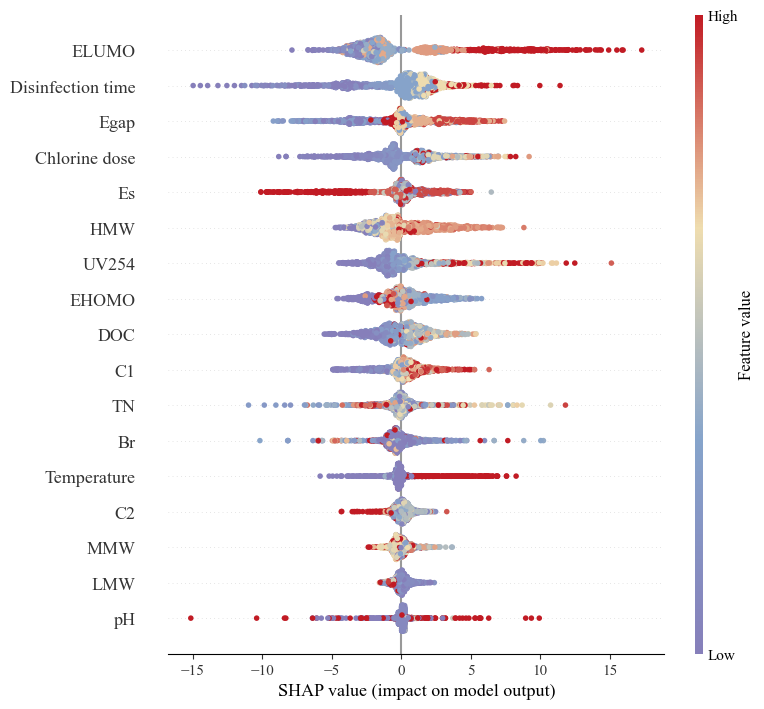

<Figure size 640x480 with 0 Axes>

In [44]:
import shap
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 15            # 控制坐标轴刻度字体大小
plt.rcParams['axes.titlesize'] = 14       # 控制图标题字号
plt.rcParams['axes.labelsize'] = 20       # 控制轴标签字体大小
plt.rcParams['xtick.labelsize'] = 11      # x轴刻度字体
plt.rcParams['ytick.labelsize'] = 11      # y轴刻度字体

# 构建四段颜色渐变：低 → 中1 → 中2 → 高

custom_cmap = LinearSegmentedColormap.from_list(
     "custom_cmap", ["#867fba", "#86a4cb", "#efddaf", "#c11b24"]
 )


# ✅ 你指定的特征名称
selected_features = [
    'DOC', 'UV254', 'Br', 'TN', 'Chlorine dose', 'Disinfection time',
    'Temperature', 'pH','C1', 'C2', 'LMW', 'MMW', 'HMW',
    'Es','EHOMO','ELUMO','Egap'
]

# 获取在 X_train 中的列索引
selected_indices = [X_train_raw.columns.get_loc(f) for f in selected_features]

# 获取 SHAP 值子集
shap_values_sub = shap_values.values[:, selected_indices]
shap_data_sub = shap_values.data[:, selected_indices]

# 计算平均绝对 SHAP 值，在所选特征中选前10
mean_abs_shap = np.abs(shap_values_sub).mean(axis=0)
top10_idx_in_selected = np.argsort(mean_abs_shap)[-20:][::-1]

# 获取对应特征名
top10_features = [selected_features[i] for i in top10_idx_in_selected]

# 构造 SHAP Explanation 对象（仅前10个）
shap_values_top10 = shap.Explanation(
    values=shap_values_sub[:, top10_idx_in_selected],
    base_values=shap_values.base_values,
    data=shap_data_sub[:, top10_idx_in_selected],
    feature_names=top10_features
)

# 绘图
plt.figure(figsize=(8, 6))
shap.plots.beeswarm(
    shap_values_top10,
    max_display=20,
    color=custom_cmap
)
plt.tight_layout()
plt.show()


In [45]:
import joblib
import numpy as np

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)


# =========================
# 7. 读取已经训练好的最终模型
# =========================
model_path = "final_CDHLQ.pkl"

final_model = joblib.load(model_path)

print("=" * 70)
print("最终CDHL-Q模型读取成功")
print(f"模型路径：{model_path}")
print("=" * 70)


# =========================
# 8. 检查训练集和测试集特征
# =========================
if hasattr(final_model, "feature_names_in_"):

    expected_features = list(final_model.feature_names_in_)

    missing_train_features = [
        col for col in expected_features
        if col not in X_train_raw.columns
    ]

    missing_test_features = [
        col for col in expected_features
        if col not in X_test_raw.columns
    ]

    if missing_train_features:
        raise ValueError(
            "X_train_raw缺少模型所需特征：\n"
            f"{missing_train_features}"
        )

    if missing_test_features:
        raise ValueError(
            "X_test_raw缺少模型所需特征：\n"
            f"{missing_test_features}"
        )

    # 严格按照模型训练时的特征名称和顺序排列
    X_train_predict = X_train_raw[expected_features].copy()
    X_test_predict = X_test_raw[expected_features].copy()

    print(f"\n模型需要的特征数量：{len(expected_features)}")

else:
    print(
        "\n警告：读取的模型没有feature_names_in_属性，"
        "将按照当前DataFrame列顺序进行预测。"
    )

    X_train_predict = X_train_raw.copy()
    X_test_predict = X_test_raw.copy()


# =========================
# 9. 检查预测数据是否存在缺失值
# =========================
train_missing = X_train_predict.isna().sum()
train_missing = train_missing[train_missing > 0]

test_missing = X_test_predict.isna().sum()
test_missing = test_missing[test_missing > 0]

if not train_missing.empty:
    print("\n训练集存在缺失值：")
    print(train_missing)

    raise ValueError(
        "X_train_raw中存在缺失值，无法直接使用模型预测。"
    )

if not test_missing.empty:
    print("\n测试集存在缺失值：")
    print(test_missing)

    raise ValueError(
        "X_test_raw中存在缺失值，无法直接使用模型预测。"
    )


# =========================
# 10. 使用读取的模型进行预测
# =========================
y_train_pred = final_model.predict(X_train_predict)
y_test_pred = final_model.predict(X_test_predict)

y_train_pred = np.asarray(y_train_pred).ravel()
y_test_pred = np.asarray(y_test_pred).ravel()

y_train_true = np.asarray(y_train).ravel()
y_test_true = np.asarray(y_test).ravel()


# =========================
# 11. 模型评价
# =========================
def evaluate(y_true, y_pred, name):
    """
    计算并输出回归模型评价指标。
    """
    if len(y_true) != len(y_pred):
        raise ValueError(
            f"{name}真实值与预测值长度不一致："
            f"{len(y_true)} != {len(y_pred)}"
        )

    r2 = r2_score(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true, y_pred
    )

    print(f"\n{name} performance:")
    print(f"R2   = {r2:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"MAE  = {mae:.4f}")

    return r2, rmse, mae


train_r2, train_rmse, train_mae = evaluate(
    y_train_true,
    y_train_pred,
    "Train"
)

test_r2, test_rmse, test_mae = evaluate(
    y_test_true,
    y_test_pred,
    "Test"
)

最终CDHL-Q模型读取成功
模型路径：final_CDHLQ.pkl

模型需要的特征数量：17

Train performance:
R2   = 0.9940
RMSE = 1.2899
MAE  = 0.8797

Test performance:
R2   = 0.9223
RMSE = 5.3263
MAE  = 3.1726
